In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
crop_df = pd.read_csv("../data/crop_production.csv")

In [7]:
crop_df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [8]:
crop_df.shape

(246091, 7)

In [9]:
crop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB


In [7]:
crop_df.describe()

,Crop_Year,Area,Production
count,246091.000000,2.460910e+05,2.423610e+05
mean,2005.643018,1.200282e+04,5.825034e+05
std,4.952164,5.052340e+04,1.706581e+07
min,1997.000000,4.000000e-02,0.000000e+00
25%,2002.000000,8.000000e+01,8.800000e+01
50%,2006.000000,5.820000e+02,7.290000e+02
75%,2010.000000,4.392000e+03,7.023000e+03
max,2015.000000,8.580100e+06,1.250800e+09


In [9]:
crop_df.isnull().sum()

State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

In [11]:
crop_df.duplicated().sum()

0

In [13]:
crop_df["State_Name"].nunique()


33

In [16]:
crop_df["District_Name"].nunique()


646

In [18]:
crop_df["Crop"].nunique()


124

In [20]:
crop_df["Season"].unique()

array(['Kharif     ', 'Whole Year ', 'Autumn     ', 'Rabi       ',
       'Summer     ', 'Winter     '], dtype=object)

In [22]:
text_columns = [
    "State_Name",
    "District_Name",
    "Season",
    "Crop"
]

for col in text_columns:
    crop_df[col] = crop_df[col].astype(str).str.strip()

In [23]:
crop_df[["Area", "Production"]].describe()

,Area,Production
count,2.460910e+05,2.423610e+05
mean,1.200282e+04,5.825034e+05
std,5.052340e+04,1.706581e+07
min,4.000000e-02,0.000000e+00
25%,8.000000e+01,8.800000e+01
50%,5.820000e+02,7.290000e+02
75%,4.392000e+03,7.023000e+03
max,8.580100e+06,1.250800e+09


In [25]:
(crop_df["Area"] < 0).sum()

0

In [27]:
(crop_df["Production"] < 0).sum()

0

In [30]:
crop_df["Yield"] = np.where(
    crop_df["Area"] > 0,
    crop_df["Production"] / crop_df["Area"],
    np.nan
)

In [11]:
crop_df.to_csv(
    "../data/crop_production_cleaned.csv",
    index=False
)

In [33]:
crop_production = (
    crop_df.groupby("Crop")["Production"]
    .sum()
    .sort_values(ascending=False)
)

In [34]:
crop_production.head(10)

Crop
Coconut         1.299816e+11
Sugarcane       5.535682e+09
Rice            1.605470e+09
Wheat           1.332826e+09
Potato          4.248263e+08
Cotton(lint)    2.970000e+08
Maize           2.733418e+08
Jute            1.815582e+08
Banana          1.461327e+08
Soyabean        1.418372e+08
Name: Production, dtype: float64

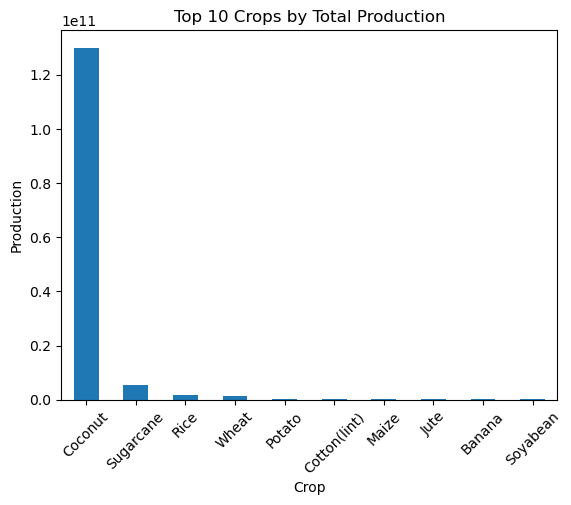

In [36]:
crop_production.head(10).plot(kind="bar")

plt.title("Top 10 Crops by Total Production")
plt.xlabel("Crop")
plt.ylabel("Production")
plt.xticks(rotation=45)
plt.show()

In [37]:
state_production = (
    crop_df.groupby("State_Name")["Production"]
    .sum()
    .sort_values(ascending=False)
)

state_production.head(10)

State_Name
Kerala                         9.788005e+10
Andhra Pradesh                 1.732459e+10
Tamil Nadu                     1.207644e+10
Uttar Pradesh                  3.234493e+09
Assam                          2.111752e+09
West Bengal                    1.397904e+09
Maharashtra                    1.263641e+09
Karnataka                      8.634298e+08
Andaman and Nicobar Islands    7.182232e+08
Punjab                         5.863850e+08
Name: Production, dtype: float64

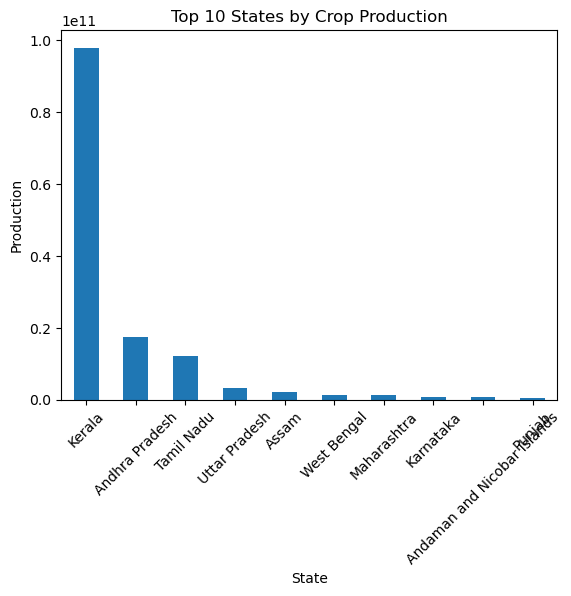

In [39]:
state_production.head(10).plot(kind="bar")

plt.title("Top 10 States by Crop Production")
plt.xlabel("State")
plt.ylabel("Production")
plt.xticks(rotation=45)
plt.show()

In [41]:
year_production = (
    crop_df.groupby("Crop_Year")["Production"]
    .sum()
)

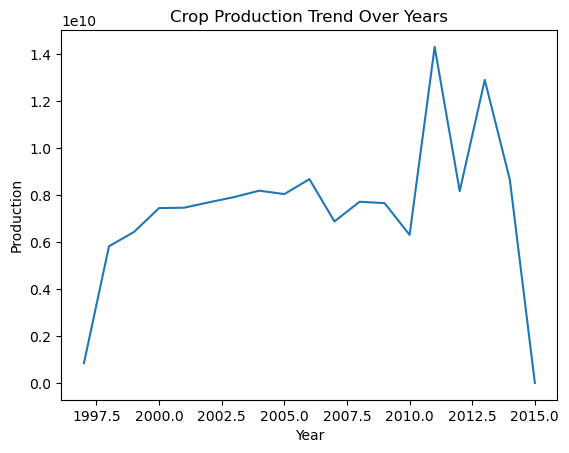

In [42]:
year_production.plot(kind="line")

plt.title("Crop Production Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Production")
plt.show()

In [44]:
season_production = (
    crop_df.groupby("Season")["Production"]
    .sum()
    .sort_values(ascending=False)
)

season_production

Season
Whole Year    1.344248e+11
Kharif        4.029970e+09
Rabi          2.051688e+09
Winter        4.345498e+08
Summer        1.706579e+08
Autumn        6.441377e+07
Name: Production, dtype: float64

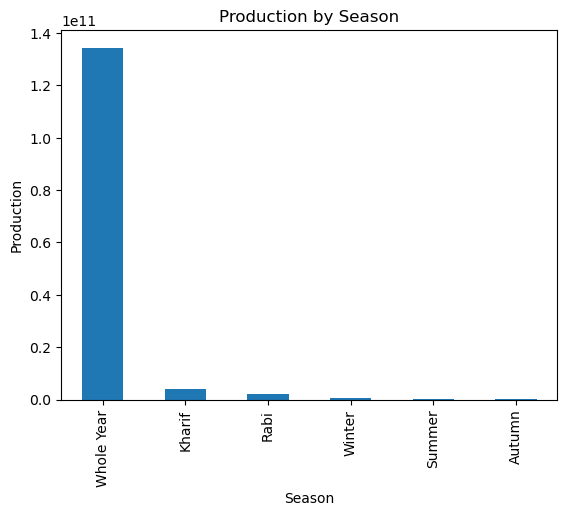

In [46]:
season_production.plot(kind="bar")

plt.title("Production by Season")
plt.xlabel("Season")
plt.ylabel("Production")
plt.show()

In [27]:
crop_yield = (
    crop_df.groupby("Crop")["Yield"]
    .mean()
    .sort_values(ascending=False)
)

In [50]:
state_crop = pd.pivot_table(
    crop_df,
    values="Production",
    index="State_Name",
    columns="Crop",
    aggfunc="sum"
)

In [51]:
district_production = (
    crop_df.groupby(
        ["State_Name", "District_Name"]
    )["Production"]
    .sum()
    .sort_values(ascending=False)
)

district_production.head(10)

State_Name      District_Name     
Kerala          KOZHIKODE             1.528074e+10
                MALAPPURAM            1.451840e+10
                THIRUVANANTHAPURAM    1.002271e+10
                THRISSUR              9.923508e+09
                KANNUR                9.783432e+09
Andhra Pradesh  EAST GODAVARI         8.271057e+09
Kerala          KASARAGOD             7.732217e+09
                KOLLAM                7.151945e+09
                PALAKKAD              6.369382e+09
                ERNAKULAM             5.021649e+09
Name: Production, dtype: float64

In [52]:
rainfall_df = pd.read_csv("../data/district_rainfall.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/district_rainfall.csv'

In [54]:
rainfall_df = pd.read_csv("../data/district wise rainfall normal.csv")

In [55]:
rainfall_df.shape
rainfall_df.info()
rainfall_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641 entries, 0 to 640
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   STATE_UT_NAME  641 non-null    object 
 1   DISTRICT       641 non-null    object 
 2   JAN            641 non-null    float64
 3   FEB            641 non-null    float64
 4   MAR            641 non-null    float64
 5   APR            641 non-null    float64
 6   MAY            641 non-null    float64
 7   JUN            641 non-null    float64
 8   JUL            641 non-null    float64
 9   AUG            641 non-null    float64
 10  SEP            641 non-null    float64
 11  OCT            641 non-null    float64
 12  NOV            641 non-null    float64
 13  DEC            641 non-null    float64
 14  ANNUAL         641 non-null    float64
 15  Jan-Feb        641 non-null    float64
 16  Mar-May        641 non-null    float64
 17  Jun-Sep        641 non-null    float64
 18  Oct-Dec   

STATE_UT_NAME    0
DISTRICT         0
JAN              0
FEB              0
MAR              0
APR              0
MAY              0
JUN              0
JUL              0
AUG              0
SEP              0
OCT              0
NOV              0
DEC              0
ANNUAL           0
Jan-Feb          0
Mar-May          0
Jun-Sep          0
Oct-Dec          0
dtype: int64

In [56]:
rainfall_df["ANNUAL"].describe()

count     641.000000
mean     1346.969579
std       838.878874
min        94.600000
25%       830.400000
50%      1116.200000
75%      1530.900000
max      7229.300000
Name: ANNUAL, dtype: float64

In [58]:
rainfall_df.sort_values(
    "ANNUAL",
    ascending=False
).head(10)

,STATE_UT_NAME,DISTRICT,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
55,MANIPUR,TAMENGLONG,48.5,229.6,224.5,431.5,539.9,1158.7,1820.9,1522.1,726.3,376.1,144.0,7.2,7229.3,278.1,1195.9,5228.0,527.3
47,MEGHALAYA,JAINTIA HILLS,33.8,44.1,115.1,282.3,598.8,1316.1,1591.3,933.8,826.3,517.7,110.9,9.7,6379.9,77.9,996.2,4667.5,638.3
46,MEGHALAYA,EAST KHASI HI,15.4,24.1,129.7,312.5,733.7,1476.2,1518.4,1019.4,607.8,277.9,40.3,10.7,6166.1,39.5,1175.9,4621.8,328.9
12,ARUNACHAL PRADESH,UPPER SIANG,74.3,176.7,362.6,397.5,408.7,801.9,653.0,417.9,686.0,264.9,86.9,71.7,4402.1,251.0,1168.8,2558.8,423.5
598,KARNATAKA,UDUPI,1.4,0.4,4.1,29.4,193.8,1081.0,1371.6,902.2,404.9,223.8,74.6,18.8,4306.0,1.8,227.3,3759.7,317.2
4,ARUNACHAL PRADESH,EAST SIANG,33.3,79.5,105.9,216.5,323.0,738.3,990.9,711.2,568.0,206.9,29.5,31.7,4034.7,112.8,645.4,3008.4,268.1
597,KARNATAKA,DAKSHIN KANDA,1.9,0.7,6.4,39.8,180.9,977.2,1227.2,833.6,313.6,236.9,82.0,15.6,3915.8,2.6,227.1,3351.6,334.5
32,ASSAM,KOKRAJHAR,10.9,27.9,45.8,216.4,461.1,822.2,864.2,677.1,462.9,159.5,18.1,6.1,3772.2,38.8,723.3,2826.4,183.7
31,ASSAM,KARIMGANJ,13.2,35.2,169.7,340.4,604.0,645.2,646.0,438.0,418.7,240.4,86.8,13.2,3650.8,48.4,1114.1,2147.9,340.4
51,MEGHALAYA,W KHASI HILL,19.7,31.1,61.3,160.5,352.3,651.5,1050.3,607.9,465.3,192.5,32.1,18.5,3643.0,50.8,574.1,2775.0,243.1


In [59]:
state_rainfall = (
    rainfall_df.groupby("STATE_UT_NAME")["ANNUAL"]
    .mean()
    .sort_values(ascending=False)
)

In [60]:
state_rainfall.head(10)

STATE_UT_NAME
MEGHALAYA                      3682.842857
GOA                            3278.500000
KERALA                         2937.392857
ARUNACHAL PRADESH              2927.375000
ANDAMAN And NICOBAR ISLANDS    2911.400000
SIKKIM                         2838.350000
MIZORAM                        2616.322222
MANIPUR                        2496.633333
TRIPURA                        2479.125000
ASSAM                          2454.359259
Name: ANNUAL, dtype: float64

In [61]:
months = [
    "JAN","FEB","MAR","APR","MAY","JUN",
    "JUL","AUG","SEP","OCT","NOV","DEC"
]

In [62]:
monthly_rainfall = rainfall_df[months].mean()

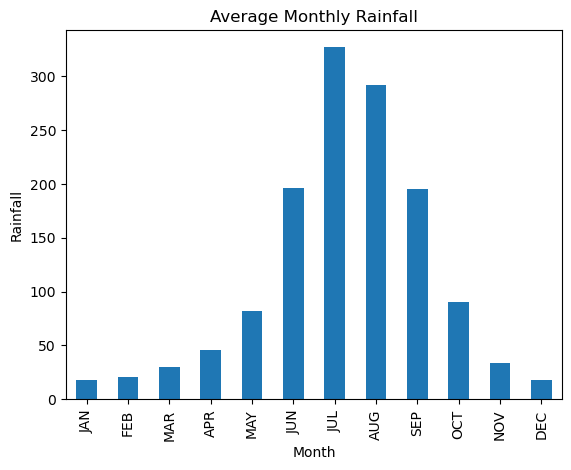

In [63]:
monthly_rainfall.plot(kind="bar")

plt.title("Average Monthly Rainfall")
plt.xlabel("Month")
plt.ylabel("Rainfall")
plt.show()

In [65]:
historical_df = pd.read_csv(
    "../data/rainfall in india 1901-2015.csv"
)

In [66]:
historical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4116 entries, 0 to 4115
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SUBDIVISION  4116 non-null   object 
 1   YEAR         4116 non-null   int64  
 2   JAN          4112 non-null   float64
 3   FEB          4113 non-null   float64
 4   MAR          4110 non-null   float64
 5   APR          4112 non-null   float64
 6   MAY          4113 non-null   float64
 7   JUN          4111 non-null   float64
 8   JUL          4109 non-null   float64
 9   AUG          4112 non-null   float64
 10  SEP          4110 non-null   float64
 11  OCT          4109 non-null   float64
 12  NOV          4105 non-null   float64
 13  DEC          4106 non-null   float64
 14  ANNUAL       4090 non-null   float64
 15  Jan-Feb      4110 non-null   float64
 16  Mar-May      4107 non-null   float64
 17  Jun-Sep      4106 non-null   float64
 18  Oct-Dec      4103 non-null   float64
dtypes: flo

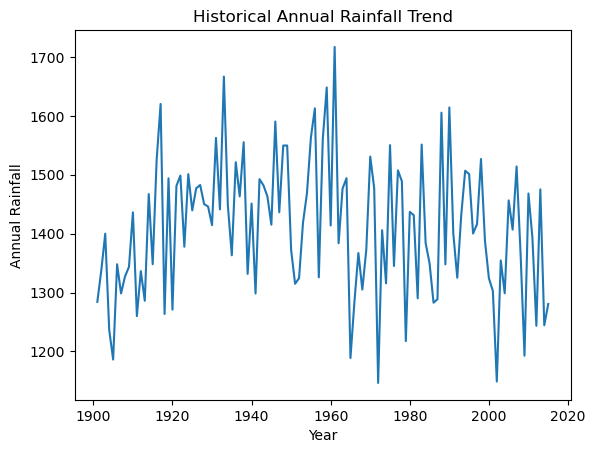

In [67]:
historical_df.groupby("YEAR")["ANNUAL"].mean().plot(
    kind="line"
)

plt.title("Historical Annual Rainfall Trend")
plt.xlabel("Year")
plt.ylabel("Annual Rainfall")
plt.show()

In [68]:
crop_df
state_production
crop_production
season_production

Season
Whole Year    1.344248e+11
Kharif        4.029970e+09
Rabi          2.051688e+09
Winter        4.345498e+08
Summer        1.706579e+08
Autumn        6.441377e+07
Name: Production, dtype: float64

In [69]:
print(crop_df.shape)
print(state_production.head())
print(crop_production.head())
print(season_production.head())

(246091, 8)
State_Name
Kerala            9.788005e+10
Andhra Pradesh    1.732459e+10
Tamil Nadu        1.207644e+10
Uttar Pradesh     3.234493e+09
Assam             2.111752e+09
Name: Production, dtype: float64
Crop
Coconut      1.299816e+11
Sugarcane    5.535682e+09
Rice         1.605470e+09
Wheat        1.332826e+09
Potato       4.248263e+08
Name: Production, dtype: float64
Season
Whole Year    1.344248e+11
Kharif        4.029970e+09
Rabi          2.051688e+09
Winter        4.345498e+08
Summer        1.706579e+08
Name: Production, dtype: float64


In [76]:
with pd.ExcelWriter("../excel/crop_analysis.xlsx") as writer:

    crop_df.to_excel(
        writer,
        sheet_name="Crop_Data",
        index=False
    )

    state_production.to_excel(
        writer,
        sheet_name="State_Production"
    )

    crop_production.to_excel(
        writer,
        sheet_name="Crop_Production"
    )

    season_production.to_excel(
        writer,
        sheet_name="Season_Production"
    )

In [78]:
with pd.ExcelWriter("../excel/crop_analysis_full.xlsx") as writer:

    crop_df.to_excel(
        writer,
        sheet_name="Crop_Data",
        index=False
    )

    state_production.to_excel(
        writer,
        sheet_name="State_Production"
    )

    crop_production.to_excel(
        writer,
        sheet_name="Crop_Production"
    )

    season_production.to_excel(
        writer,
        sheet_name="Season_Production"
    )

In [72]:
import os

print(os.getcwd())

c:\Users\DELL\Desktop\crop-analysis\python


In [73]:
print(os.listdir())

['01_data_cleaning.ipynb']


In [74]:
import pandas as pd

df = pd.read_csv("../data/crop_production.csv")

print(df.shape)

(246091, 7)


In [79]:
print(crop_df.shape)

(246091, 8)


In [ ]:
crop_df.to_csv("../data/crop_production_cleaned.csv", index=False)

In [2]:
crop_df.to_csv("../data/crop_production_cleaned.csv", index=False)

NameError: name 'crop_df' is not defined

In [3]:
import pandas as pd
import numpy as np

In [4]:
crop_df = pd.read_csv("../data/crop_production.csv")

In [5]:
crop_df.head()


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [6]:
crop_df.columns


Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Production'],
      dtype='object')

In [7]:
crop_df.shape

(246091, 7)

In [8]:
crop_df.isnull().sum()

State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

In [10]:
os.listdir()

NameError: name 'os' is not defined

In [11]:
import os
import pandas as pd

print(os.getcwd())

c:\Users\DELL\Desktop\crop-analysis\python


In [12]:
print(os.listdir())

['01_data_cleaning.ipynb']


In [13]:
crop_df.to_csv("../data/crop_production_cleaned.csv", index=False)

In [14]:
import os

print(os.listdir("../"))

['data', 'excel', 'images', 'powerBI', 'python', 'README.md', 'sql']


In [15]:
print(os.listdir("../data"))

['crop_production.csv', 'crop_production_cleaned.csv', 'district wise rainfall normal.csv', 'rainfall in india 1901-2015.csv']


In [16]:
import pandas as pd

crop_df = pd.read_csv("../data/crop_production_cleaned.csv")

In [17]:
crop_df.columns

Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Production'],
      dtype='object')

In [18]:
crop_df.shape

(246091, 7)

In [19]:
crop_df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [20]:
import pandas as pd

crop_df = pd.read_csv("../data/crop_production_cleaned.csv")

print(crop_df.columns.tolist())

['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']


In [21]:
import numpy as np

crop_df["Yield"] = np.where(
    crop_df["Area"] > 0,
    crop_df["Production"] / crop_df["Area"],
    np.nan
)

In [22]:
crop_df[["Area", "Production", "Yield"]].head()

,Area,Production,Yield
0,1254.0,2000.0,1.594896
1,2.0,1.0,0.500000
2,102.0,321.0,3.147059
3,176.0,641.0,3.642045
4,720.0,165.0,0.229167


In [23]:
crop_df.to_csv("../data/crop_production_cleaned.csv", index=False)

In [3]:
crop_df.head()

NameError: name 'crop_df' is not defined

In [4]:
crop_df.head()

NameError: name 'crop_df' is not defined

In [12]:
crop_df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0,0.500000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0,3.147059
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0,3.642045
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0,0.229167


In [13]:
crop_df.shape

(246091, 8)

In [14]:
crop_df.columns

Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Production', 'Yield'],
      dtype='object')

In [15]:
crop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
 7   Yield          242361 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 15.0+ MB


In [19]:
crop_df.isnull().sum()

State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
Yield            3730
dtype: int64

In [17]:
crop_df.duplicated().sum()

0

In [20]:
crop_df.dtypes

State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Area             float64
Production       float64
Yield            float64
dtype: object

In [21]:
crop_df['yield_value'].isnull().sum()

KeyError: 'yield_value'

In [22]:
crop_df['yield'].isnull().sum()

KeyError: 'yield'

In [23]:
crop_df['Yield'].isnull().sum()

3730

In [24]:
crop_df[crop_df['Yield'].isnull()][
    ['crop', 'area', 'production', 'Yield']
].head(20)

KeyError: "['crop', 'area', 'production'] not in index"

In [25]:
crop_df[crop_df['Yield'].isnull()][
    ['crop', 'area', 'production', 'Yield']
].head(20)

KeyError: "['crop', 'area', 'production'] not in index"

In [31]:
crop_df[crop_df['Yield'].isnull()][
    ['Crop', 'Area', 'Production', 'Yield']
].head(20)

,Crop,Area,Production,Yield
46,Arecanut,795.67,NaN,NaN
51,Dry chillies,17.00,NaN,NaN
623,Moong(Green Gram),1000.00,NaN,NaN
630,Horse-gram,1000.00,NaN,NaN
698,Rapeseed &Mustard,8.00,NaN,NaN
723,Other Kharif pulses,1.00,NaN,NaN
1153,Wheat,4.00,NaN,NaN
1317,Wheat,2.00,NaN,NaN
1419,Moong(Green Gram),1000.00,NaN,NaN
1423,Small millets,1000.00,NaN,NaN


In [32]:
crop_df[
    crop_df['Yield'].isnull() & crop_df['Production'].notnull()
][['Crop', 'Area', 'Production', 'Yield']].head(20)

,Crop,Area,Production,Yield


In [33]:
print("Missing Yield:", crop_df['Yield'].isnull().sum())
print("Missing Production:", crop_df['Production'].isnull().sum())

Missing Yield: 3730
Missing Production: 3730


In [34]:
crop_df[
    crop_df['Production'].isnull()
][['Crop', 'Area', 'Production', 'Yield']].head(20)

,Crop,Area,Production,Yield
46,Arecanut,795.67,NaN,NaN
51,Dry chillies,17.00,NaN,NaN
623,Moong(Green Gram),1000.00,NaN,NaN
630,Horse-gram,1000.00,NaN,NaN
698,Rapeseed &Mustard,8.00,NaN,NaN
723,Other Kharif pulses,1.00,NaN,NaN
1153,Wheat,4.00,NaN,NaN
1317,Wheat,2.00,NaN,NaN
1419,Moong(Green Gram),1000.00,NaN,NaN
1423,Small millets,1000.00,NaN,NaN


In [35]:
crop_df[crop_df['Production'].isnull()][
    ['State', 'District', 'Year', 'Season', 'Crop', 'Area', 'Production', 'Yield']
].head(20)

KeyError: "['State', 'District', 'Year'] not in index"

In [36]:
crop_df.columns.tolist()

['State_Name',
 'District_Name',
 'Crop_Year',
 'Season',
 'Crop',
 'Area',
 'Production',
 'Yield']

In [37]:
crop_df[crop_df['Production'].isnull()][
    ['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production', 'Yield']
].head(20)

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield
46,Andaman and Nicobar Islands,NICOBARS,2005,Whole Year,Arecanut,795.67,NaN,NaN
51,Andaman and Nicobar Islands,NICOBARS,2005,Whole Year,Dry chillies,17.00,NaN,NaN
623,Andhra Pradesh,ANANTAPUR,2007,Kharif,Moong(Green Gram),1000.00,NaN,NaN
630,Andhra Pradesh,ANANTAPUR,2007,Rabi,Horse-gram,1000.00,NaN,NaN
698,Andhra Pradesh,ANANTAPUR,2009,Rabi,Rapeseed &Mustard,8.00,NaN,NaN
723,Andhra Pradesh,ANANTAPUR,2010,Kharif,Other Kharif pulses,1.00,NaN,NaN
1153,Andhra Pradesh,CHITTOOR,2001,Rabi,Wheat,4.00,NaN,NaN
1317,Andhra Pradesh,CHITTOOR,2004,Rabi,Wheat,2.00,NaN,NaN
1419,Andhra Pradesh,CHITTOOR,2007,Kharif,Moong(Green Gram),1000.00,NaN,NaN
1423,Andhra Pradesh,CHITTOOR,2007,Kharif,Small millets,1000.00,NaN,NaN


In [38]:
total_rows = len(crop_df)

missing_production = crop_df['Production'].isnull().sum()

print("Total rows:", total_rows)
print("Missing Production:", missing_production)
print(
    "Missing Production %:",
    round((missing_production / total_rows) * 100, 2),
    "%"
)

Total rows: 246091
Missing Production: 3730
Missing Production %: 1.52 %
